# PLS: Partial Least Squares Regression

Partial Least Squares or PLS is a regression technique which is used for predicting a response $Y$ using a set of predictors $X$ using a small number of latent components. The latent components are linear combinition of predictors which can be regressed on instead of the original set of regressors $X$. This is particularly helpful if we have a large number of correlated predictors. In this scenario, oridinary least squares fails whereas PLS chooses its components to capture the directions of $X$ that are most predictive of $Y$.   

In this documentation, we will depomstrate implementation of Plskern using `BigRiverEssence.plskern` on a `gasoline` dataset. 


## The method

Let $Y$ be response variable and $X$ be a matrix of regressors. PLS finds a direction $w$ (one as a time) in the predictor space such that it maximizes the covariance between the projected predictors $Xw$ and the response $Y$. It considers the following optimization problem: $$\max_{w} \; \operatorname{cov}(Xw, Y) \quad \text{subject to } \|w\|_2 = 1.$$

The scores $t = Xw$ are the values of the samples along that component. The predictor
and response loadings ($p$ and $q$) are used for describing how $X$ and $Y$ are related to the scores. We then deflate or remove the component from the cross covariance. This enables the next component to captures new predictive structure rather than repeating what has been found. After we obtain $k$ components, prediction reduces to a linear model $\hat Y = \text{intercept} +
X B$, where the coefficient matrix $B$ is assembled from the accumulated weights and loadings.


`plskern` of `BigRiverEssence` implements the improved kernel algorithms used by Dayal & MacGregor (1997) where they use  cross-product matrices for efficient computation. The number of components, `nlv`, is the main tuning parameter of `plskern` where 
a small value leads underfitting and vice versa.


## The data

We use the `gasoline` dataset from `pls` package of R. The dataset contains $60$ samples where each
has an octane number, which is the response, and a $401$-point NIR spectrum ($900–1700$ nm), which are the predictors. 


In [ ]:
using BigRiverEssence
const BRE = BigRiverEssence
using RCall, Plots, Statistics, Random
gr()

R"""
library(pls)
data(gasoline)
octane <- as.numeric(gasoline$octane)
NIR    <- unclass(gasoline$NIR)
"""
octane = rcopy(R"octane")            # 60 responses
NIR    = rcopy(R"NIR")               # 60 × 401 spectra
wl     = collect(900:2:1700)         # the known wavelength grid (nm)
size(NIR), length(octane)

((60, 401), 60)

## Train/test split

Now, since PLS is a predictive model, we consider a hold out test set. We use a random seed for reproduction.



In [20]:
Random.seed!(42)
idx = shuffle(1:size(NIR, 1))
train, test = idx[1:40], idx[41:end]

Xtr = Matrix{Float64}(NIR[train, :]); ytr = reshape(Float64.(octane[train]), :, 1)
Xte = Matrix{Float64}(NIR[test, :]);  yte = reshape(Float64.(octane[test]),  :, 1)


20×1 Matrix{Float64}:
 85.4
 88.9
 88.0
 85.25
 88.1
 86.3
 88.4
 88.2
 88.0
 85.1
 88.7
 87.15
 88.45
 88.45
 88.25
 87.6
 86.0
 84.5
 88.45
 85.3

It is important to keep in mind that `plskern` takes the
response as a matrix which gives it flexibility to handles more than one responses uniformly. Hence we reshaped `ytr` and `yte` to $n\times 1$ matrices. 


## Fitting the model `plskern`

We now fit a PLS model with $5$ latent components.


In [ ]:
m = BRE.plskern(Xtr, ytr; nlv = 5)

plskernStructure{Float64}([-0.009012807050039057 0.005655637459323742 … -0.0016491664403859197 -0.010106177194324323; -0.007255148997723867 0.008005041099358718 … -0.0041163919649913104 -0.022434972642045047; … ; -0.030750119828483073 -0.02415520568240082 … -0.2850865903563609 0.06827985179446464; 0.010966550990882519 0.042275971950273945 … -0.29491050468642 0.2929412628543613], [-0.01147953052128346 -0.006738900698935337 … 0.0006763769587101984 0.032264365988856236; -0.010746572008849011 -0.004203368137367935 … 0.0010461439309665341 0.022023419682194678; … ; -0.020214753437328488 -0.01894005953154278 … -0.3007985411344508 0.11432465023825829; -0.007472242695847204 0.06034905277471371 … -0.3623195365146401 0.37908829968794544], [4.686952718138948 17.872119565915618 … 1.9144238750920581 9.030216122367058], [-0.009012807050039057 0.0017246742651612374 … 0.025438643254075764 -0.004252463394936391; -0.007255148997723867 0.004840685808063103 … 0.022946156494351503 -0.01715480767521335; … ; 

The function returns the full PLS factorization: the weights `W` and
`R`, the predictor and response loadings `P` and `Q`, the scores `T`, and the
centering means and scales.

In [23]:
@show size(m.W)
@show size(m.P)
@show size(m.Q)
@show size(m.T)

size(m.W) = (401, 5)
size(m.P) = (401, 5)
size(m.Q) = (1, 5)
size(m.T) = (40, 5)


(40, 5)


## Predicting with `plskernpredict`

We now predict octane for the held-out samples in the test set and compare with the measured values.


rmse = 0.1821860582426445


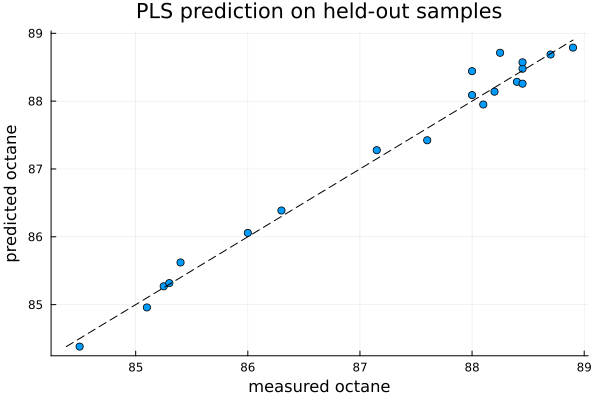

In [ ]:
ŷ = BRE.plskernpredict(m, Xte)

rmse = sqrt(mean((vec(ŷ) .- vec(yte)).^2))     # test-set prediction error
@show rmse
scatter(vec(yte), vec(ŷ); legend = false,
    xlabel = "measured octane", ylabel = "predicted octane",
    title = "PLS prediction on held-out samples")
lims = extrema(vcat(vec(yte), vec(ŷ)))
plot!(collect(lims), collect(lims); color = :black, linestyle = :dash)


We see from the above plot that the predicted octane values fall veryclose to the dashed $45°$ line of perfect prediction. We also get a test-set RMSE of about 0.1822 octane units. This shows a good calibration from spectra alone, on samples the model never saw during fitting.


## The regression coefficients with `plskerncoef`

The function `plskerncoef` is used for assembling the coefficient vector $B$ and intercept that map a raw
spectrum directly to a predicted octane. We can  plot $B$ against wavelength to see which
spectral regions drive the prediction.



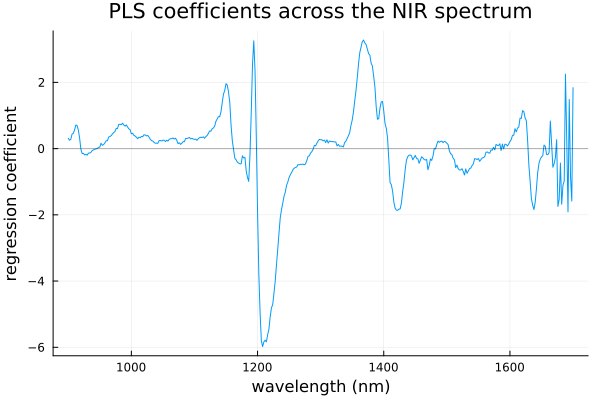

In [ ]:
B, intercept = BRE.plskerncoef(m)

plot(wl, vec(B); legend = false,
    xlabel = "wavelength (nm)", ylabel = "regression coefficient",
    title = "PLS coefficients across the NIR spectrum")
hline!([0], color = :black, alpha = 0.3)

we see from the plot that most wavelengths carry small coefficients, with few high peaks where the spectral
regions are most informative about octane. This is the interpretable payoff of a linear
calibration where the coefficients point back to the chemistry. 

## Projecting with `plskerntransform`

The other function `plskerntransform` is used for projecting samples onto the PLS latent space or their scores. If we color
the scores by octane, it will shows that the components are organized around the response. This is the
supervised counterpart to the variance-only components of PCA.

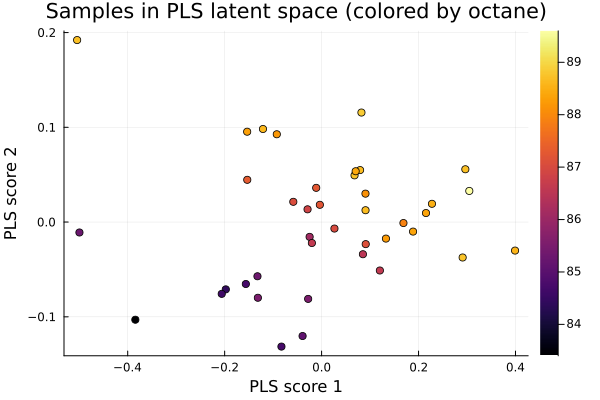

In [ ]:
Ttr = BRE.plskerntransform(m, Xtr)

scatter(Ttr[:, 1], Ttr[:, 2]; zcolor = vec(ytr), colorbar = true, legend = false,
    xlabel = "PLS score 1", ylabel = "PLS score 2",
    title = "Samples in PLS latent space (colored by octane)")

After coloring the score scatter by octane, in the above plot, we get to know what makes PLS supervised. We see the samples
lining up along the first component by their octane value where dark (low-octane) points to
the left and bright (high-octane) to the right. The first PLS component is giving the direction
of the spectra most predictive of octane, not merely the direction of greatest
spectral variance as in PCA. That is why regressing on a few PLS scores captures the
response so efficiently.

## Summary

We saw that from 60 spectra with 401 correlated predictors, `plskern` were able to built a handful of latent
components that predict octane accurately on held-out samples. This is the setting where PLS
outperforms ordinary regression. 

`plskern` is most suitable in regression problems where there are huge number of correlated variables where ordinary least squares. In this example, we used the `gasoline` dataset which has $401$ variables but only $60$ samples. `plskern` can be used in any similar type of datasets.
